In [17]:
import sys
import os
import multiprocessing as mp
import numpy as np

# Добавляем корневую папку проекта
sys.path.append('/home/silvarum/TransPath_Adaptation')

from dataset_generation.dataset_generator import generate_dataset_by_label

def generate_dataset_parallel(label, total_N, num_processes=32):
   # Разделяем работу между процессами
   chunk_size = total_N // num_processes
   remainder = total_N % num_processes
   
   # Создаем аргументы для каждого процесса
   args = []
   for i in range(num_processes):
       n = chunk_size + (1 if i < remainder else 0)  # распределяем остаток
       args.append((label, n))
   
   # Запускаем параллельно
   with mp.Pool(num_processes) as pool:
       results = pool.starmap(generate_dataset_by_label, args)
   
   # Склеиваем результаты
   return np.concatenate(results, axis=0)

In [ ]:
dataset = generate_dataset_parallel(label="train1", total_N=64000, num_processes=16)
print(f"Итоговый размер: {dataset.shape}")

train1 are generating: 100%|██████████| 8000/8000 [00:25<00:00, 312.91it/s]

train1 are generating: 100%|██████████| 8000/8000 [00:25<00:00, 312.08it/s]

train1 are generating: 100%|██████████| 8000/8000 [00:25<00:00, 311.82it/s]

Dijkstra calculation: 100%|██████████| 8000/8000 [02:55<00:00, 45.67it/s]s]

Dijkstra calculation: 100%|██████████| 8000/8000 [02:55<00:00, 45.62it/s]]

Mark start: 100%|██████████| 8000/8000 [00:01<00:00, 5305.32it/s]95.62it/s]

Mark start:  72%|███████▏  | 5740/8000 [00:01<00:00, 4573.72it/s]4it/s]t/s]

Mark start: 100%|██████████| 8000/8000 [00:01<00:00, 5095.81it/s]90.94it/s]

Mark start: 100%|██████████| 8000/8000 [00:01<00:00, 5161.00it/s]91.73it/s]

train1 are generating: 100%|██████████| 9063/9063 [00:26<00:00, 346.99it/s]

Dijkstra calculation: 100%|██████████| 9063/9063 [03:07<00:00, 48.39it/s]

Mark start: 100%|██████████| 9063/9063 [00:01<00:00, 5689.02it/s].33it/s]

Mark start: 100%|██████████| 9063/9063 [00:01<00:00, 5136.50it/s]


Итоговый размер: (512000, 64, 64, 4)


In [20]:
valset = generate_dataset_parallel(label="train1", total_N=64000, num_processes=16)
print(f"Итоговый размер: {valset.shape}")

train1 are generating: 100%|█████████▉| 3996/4000 [00:09<00:00, 412.92it/s]

train1 are generating: 100%|██████████| 4000/4000 [00:09<00:00, 402.21it/s]

train1 are generating: 100%|██████████| 4000/4000 [00:09<00:00, 401.92it/s]

Mark start: 100%|██████████| 4515/4515 [00:00<00:00, 6035.31it/s]


Итоговый размер: (64000, 64, 64, 4)


In [21]:
np.save(file="strong_val.npy", arr=valset)

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

def plot_map(T, i, save_path=None):
    """
    Визуализация {i}-ой карты с начальной и конечной точками, а также результатом Дейкстры с прозрачными областями вне карты.

    Параметры:
        T (np.ndarray): Тензор данных размером (N, 64, 64, 4).
        i (int): Индекс карты для отображения.
        save_path (str): Путь для сохранения изображения (если указан).
    """
    B = T[..., 1]
    C = T[..., 2]
    D = T[..., 3]

    # Копируем массив расстояний и заменяем нули на NaN для прозрачных областей
    distances = np.copy(C[i])
    distances[distances == 0] = np.nan

    # Создаем цветовую карту с прозрачным фоном
    cmap = plt.cm.viridis
    cmap.set_bad(color=(0, 0, 0, 0))  # Прозрачный цвет для NaN

    plt.figure(figsize=(6, 6), dpi=100)
    plt.title(f"Map {i + 1}: Landscape with Points")

    # Визуализация карты с прозрачным фоном для областей вне карты
    img = plt.imshow(distances, cmap=cmap, vmin=0, vmax=np.nanmax(distances))

    # Наносим начальную и конечную точки
    start_point = np.argwhere(D[i] == 1)
    end_point = np.argwhere(B[i] == 1)

    if len(start_point) > 0:
        plt.scatter(start_point[0, 1], start_point[0, 0], color='blue', label='Start', s=100)
    if len(end_point) > 0:
        plt.scatter(end_point[0, 1], end_point[0, 0], color='red', label='End', s=100)

    plt.legend()
    plt.colorbar(img, label='Distance to End Point')

    # Сохраняем изображение, если указан путь
    if save_path:
        plt.savefig(save_path, transparent=True, bbox_inches='tight')

    plt.show()

In [15]:
def plot_multiple_maps(T, num_maps=100, save_dir="maps"):
    """
    Отображение нескольких карт с сохранением изображений.

    Параметры:
        T (np.ndarray): Тензор данных размером (N, 64, 64, 4).
        num_maps (int): Количество карт для отображения.
        save_dir (str): Директория для сохранения изображений.
    """
    import os

    # Создаем директорию для сохранения изображений, если её нет
    os.makedirs(save_dir, exist_ok=True)

    for i in range(min(num_maps, T.shape[0])):
        save_path = os.path.join(save_dir, f"map_{i + 1}.pdf")
        plot_map(T, i, save_path=save_path)

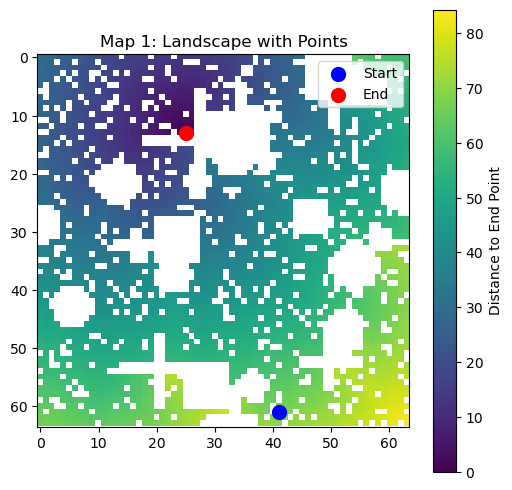

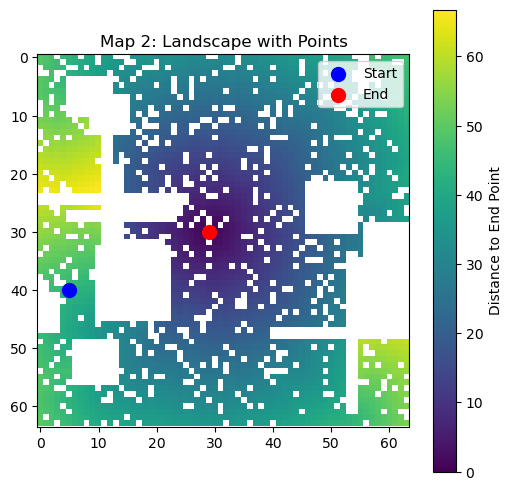

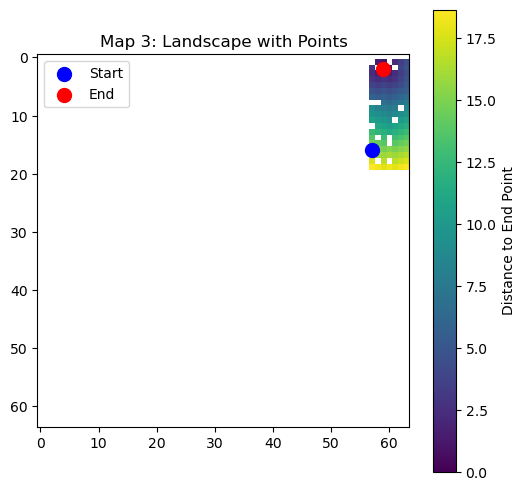

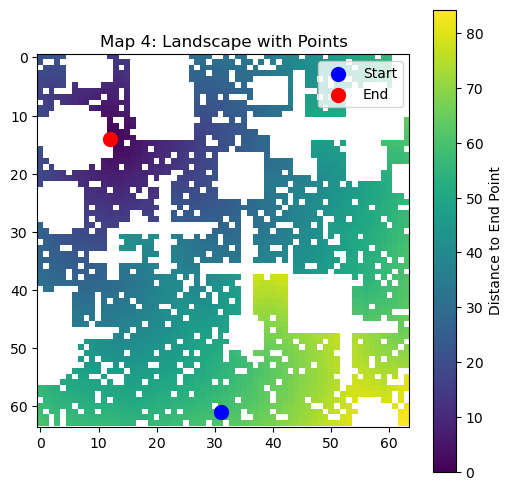

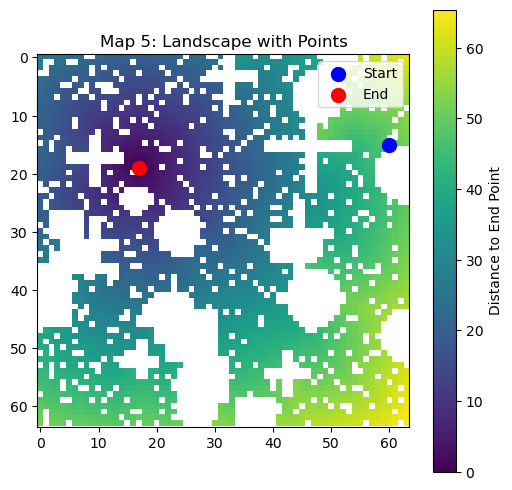

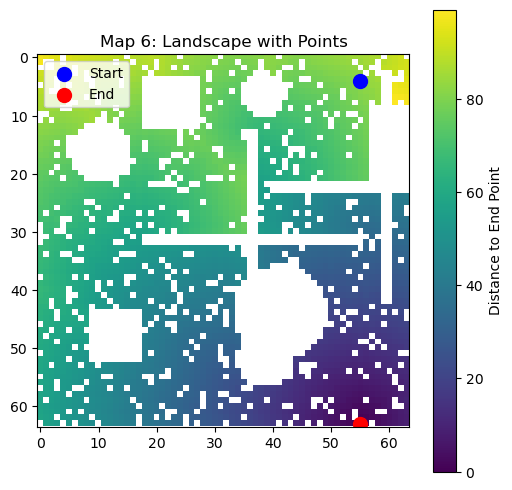

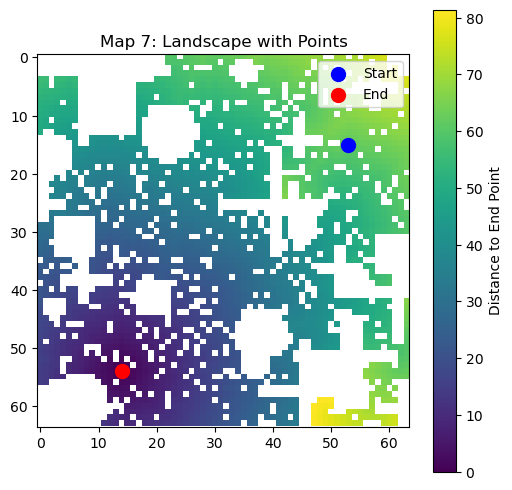

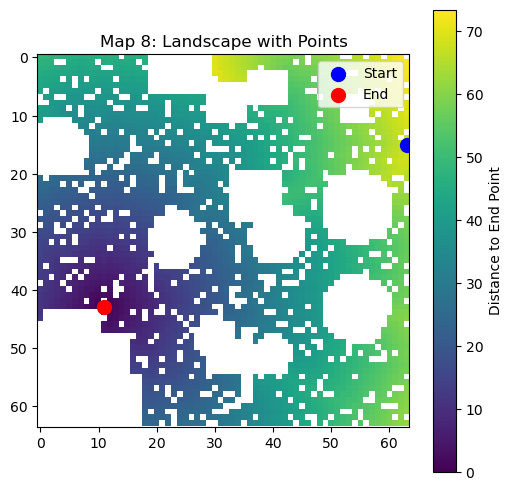

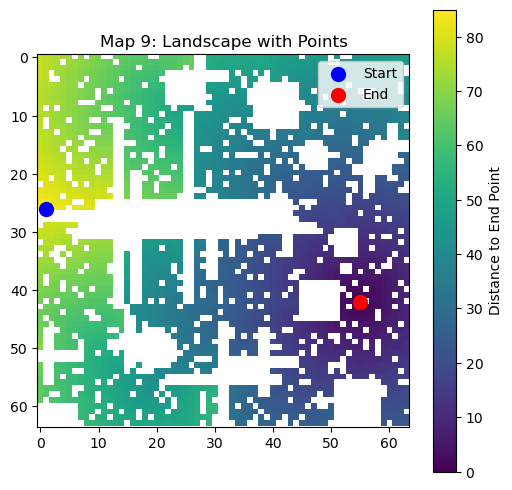

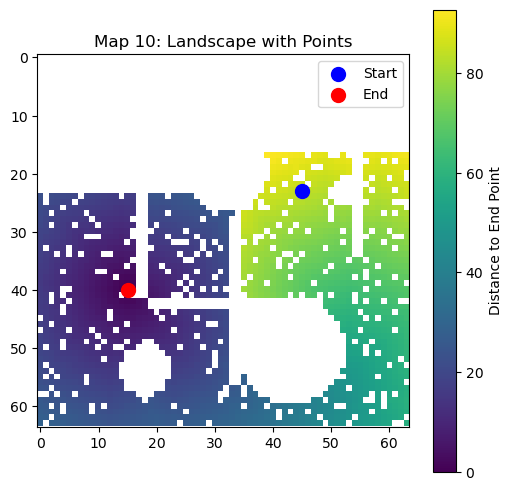

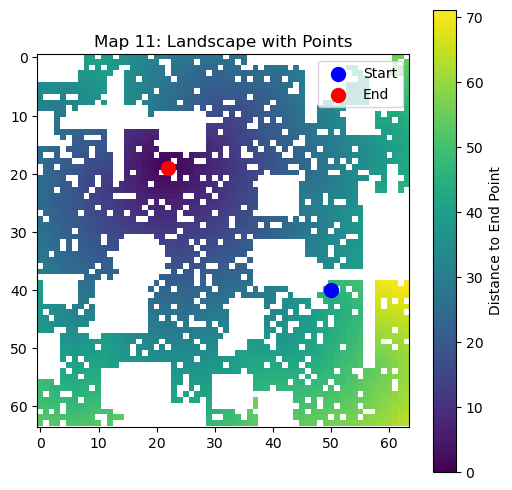

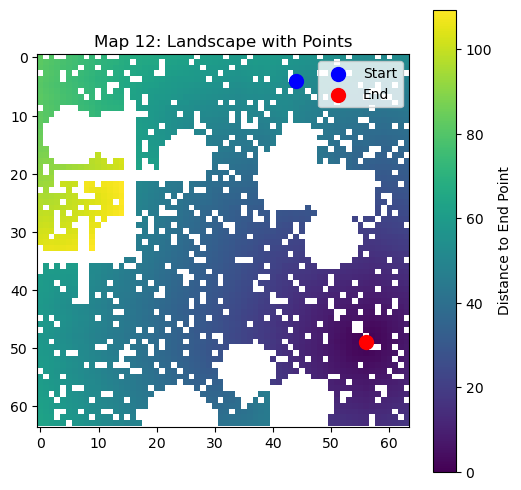

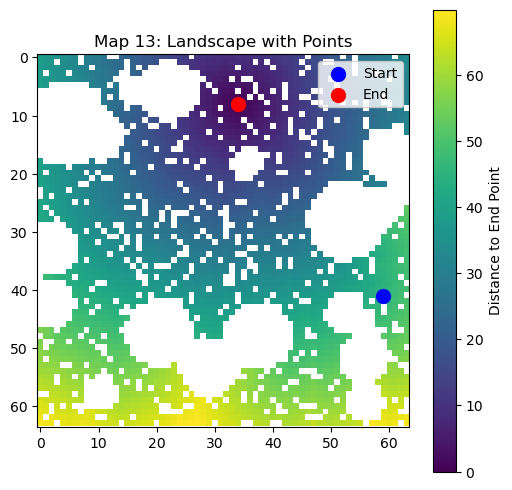

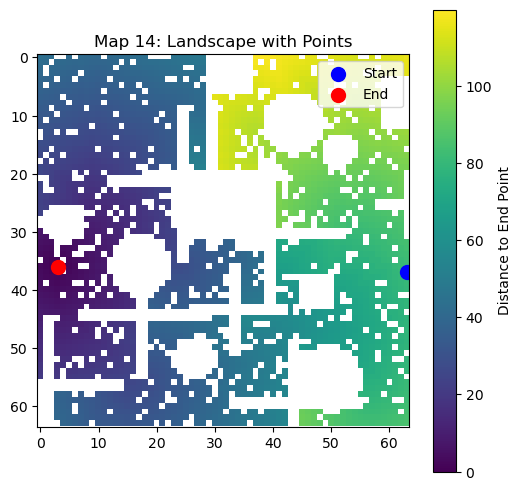

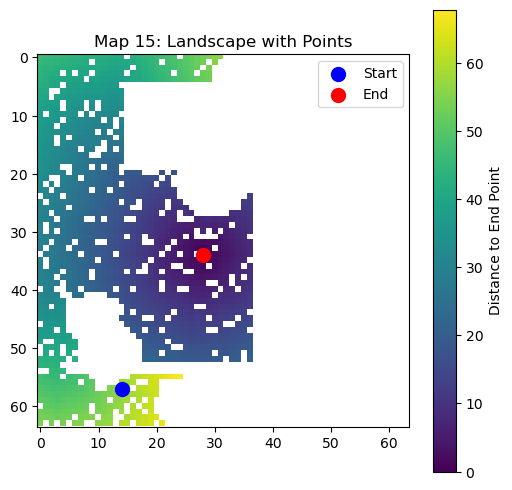

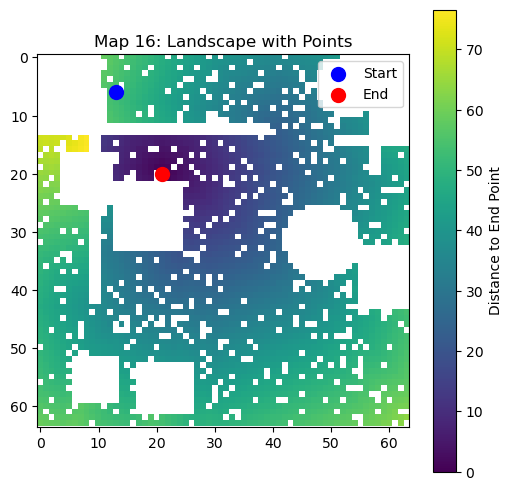

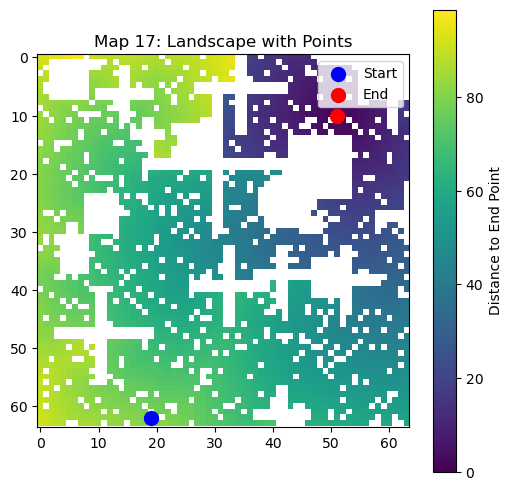

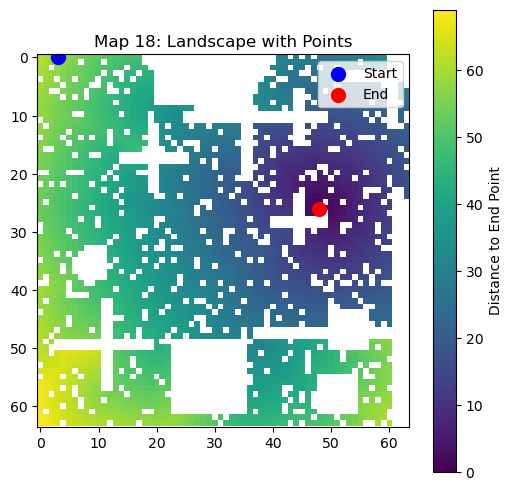

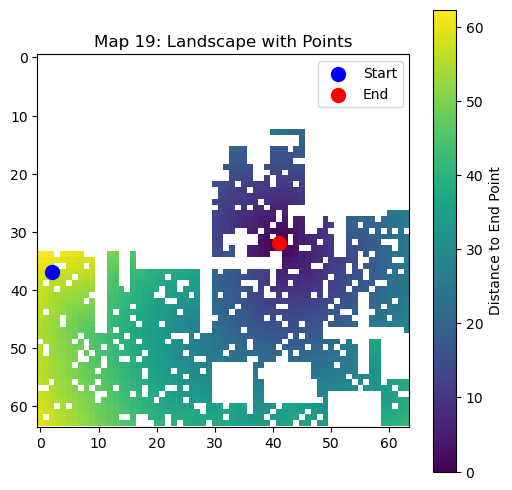

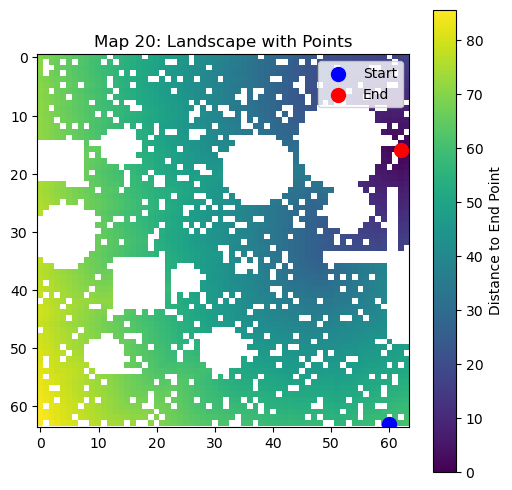

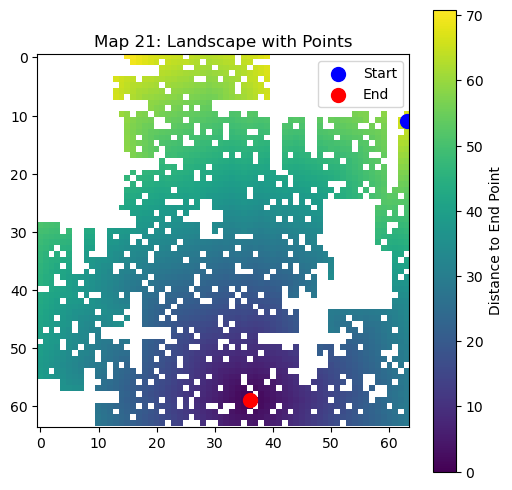

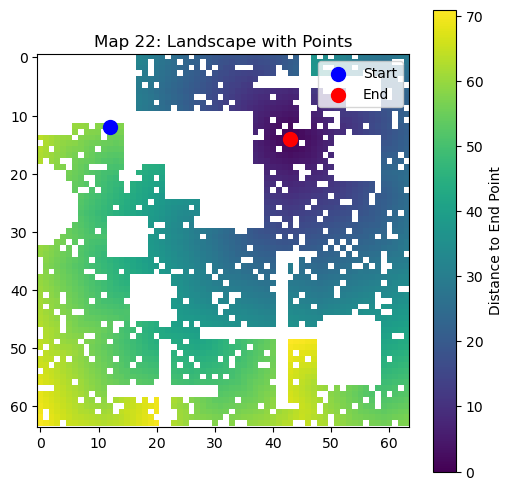

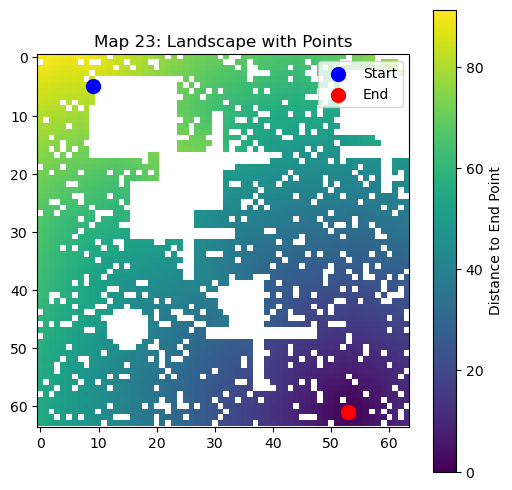

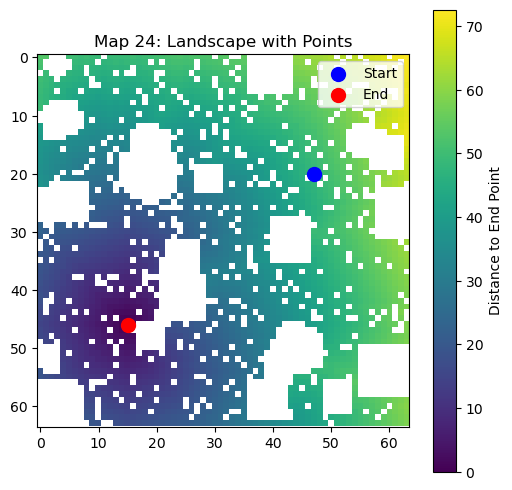

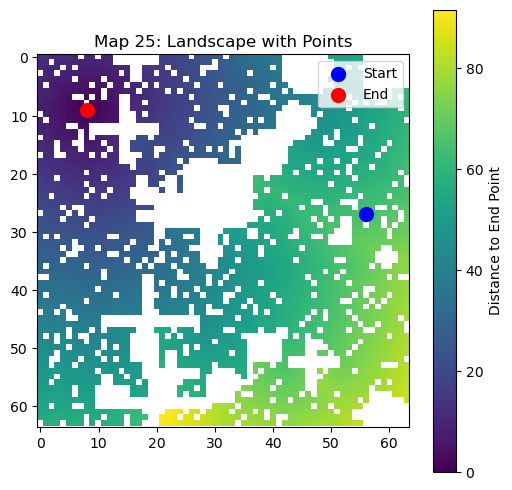

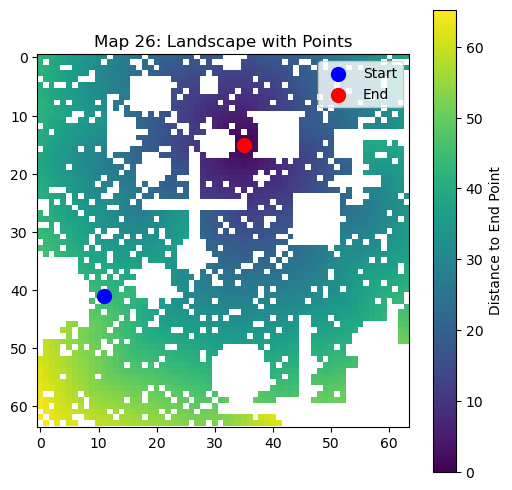

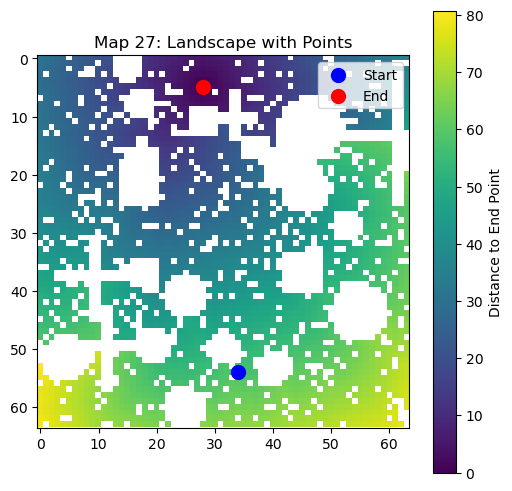

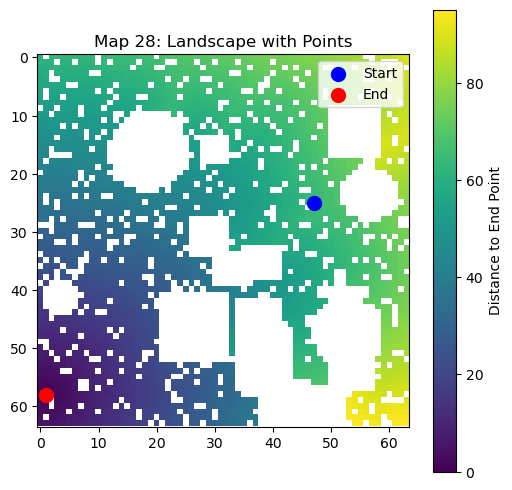

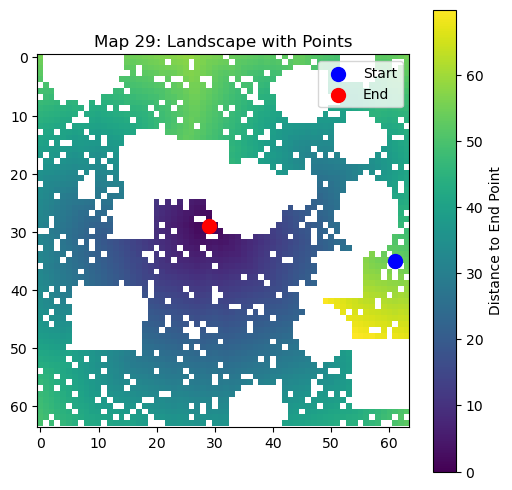

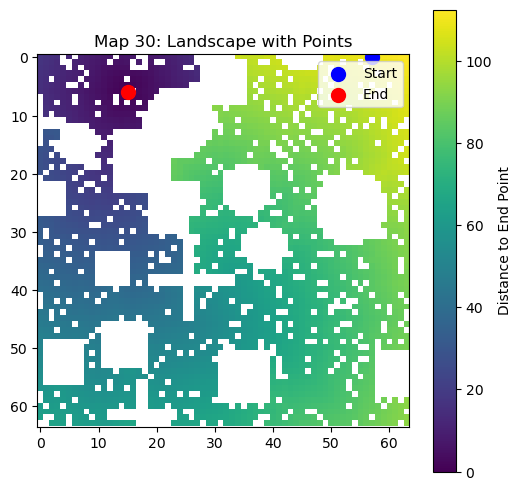

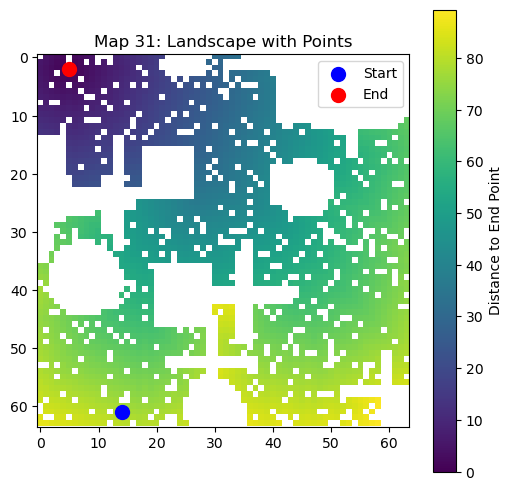

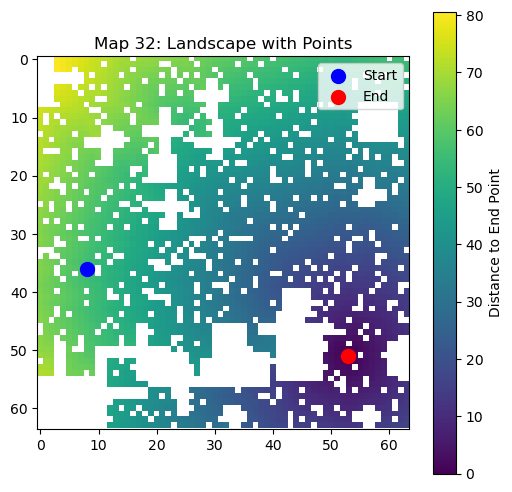

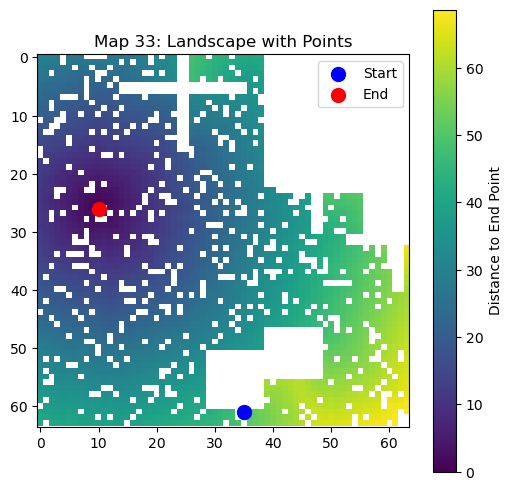

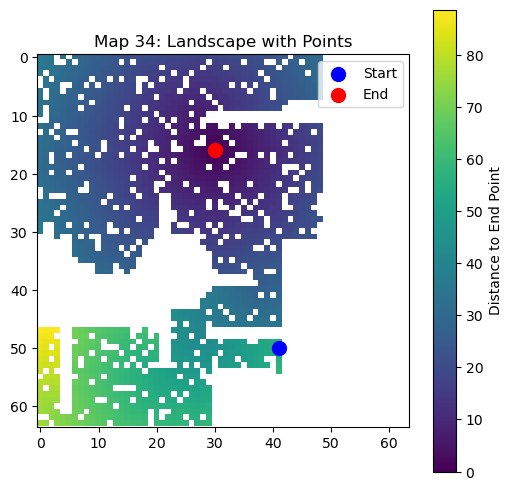

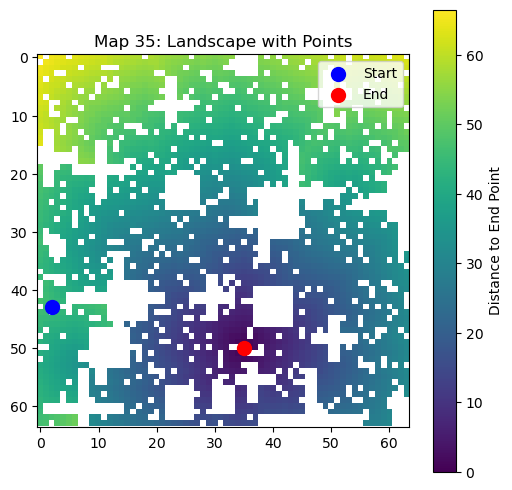

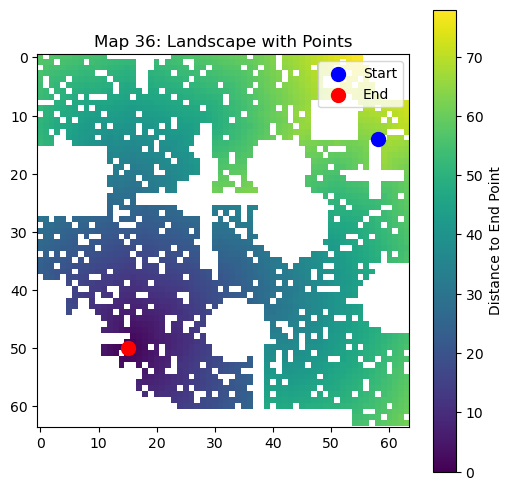

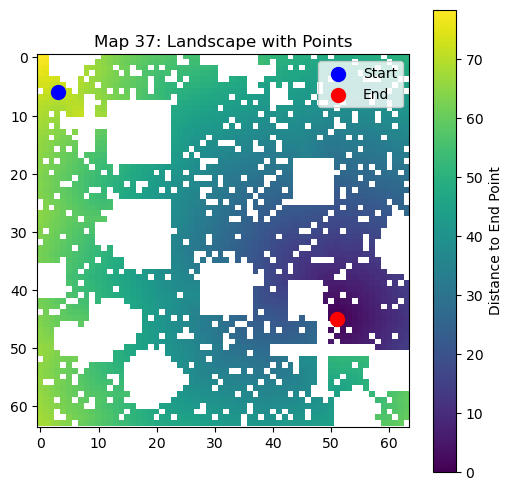

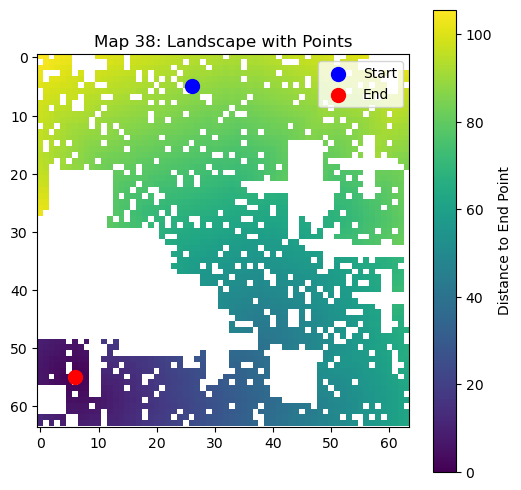

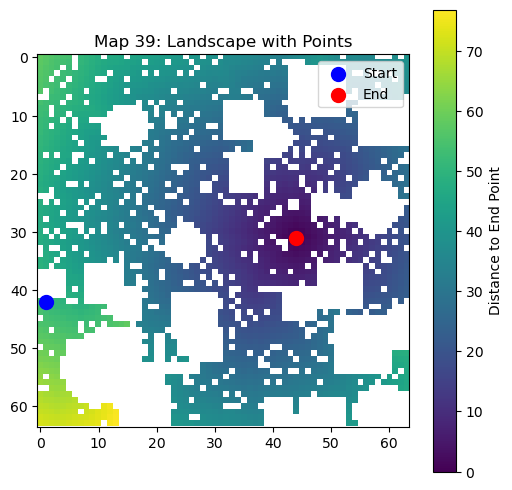

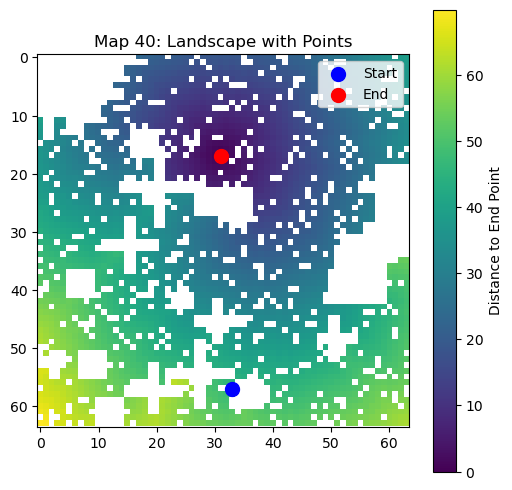

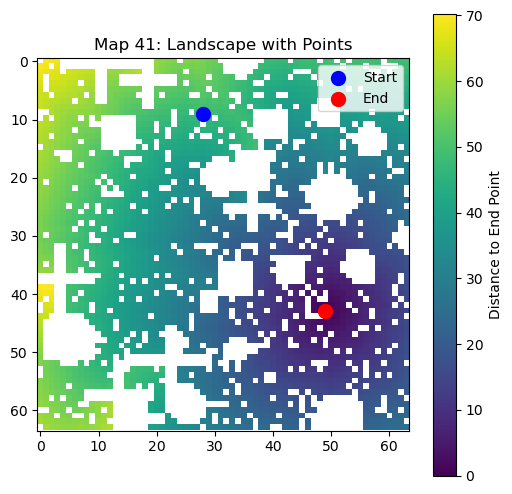

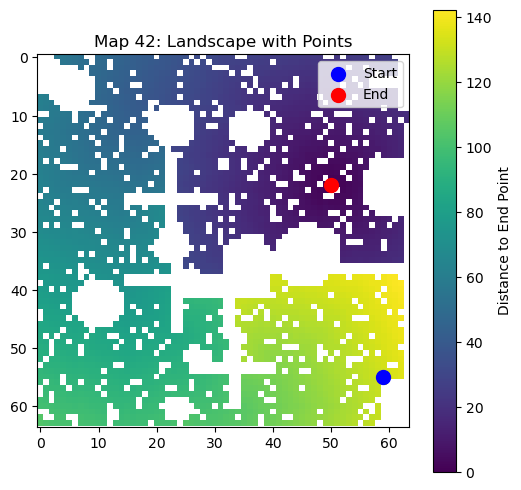

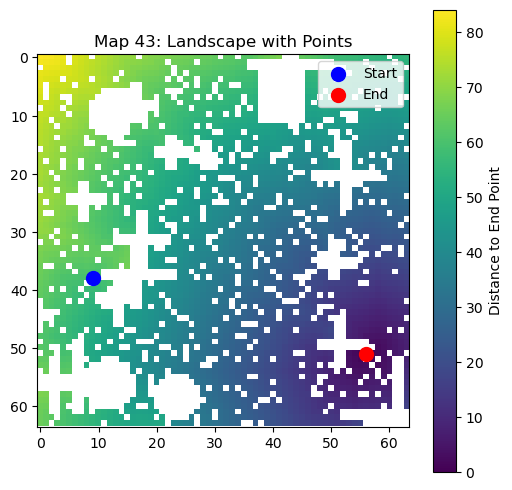

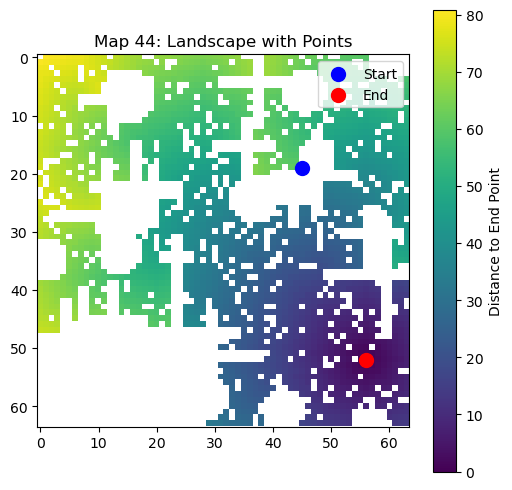

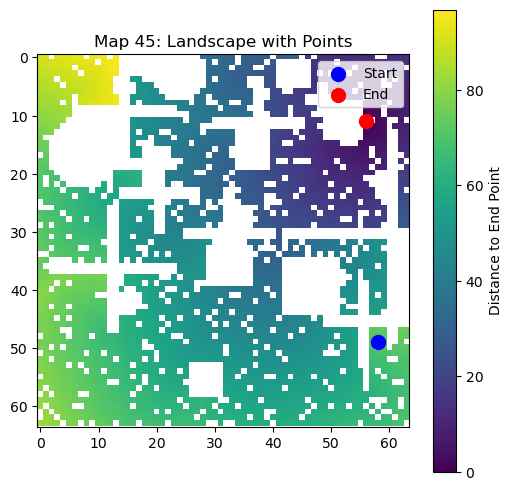

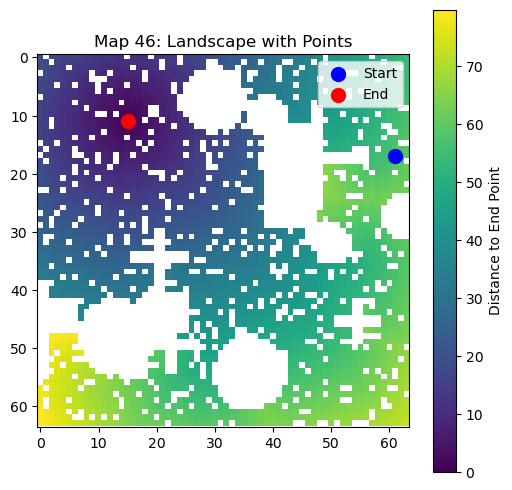

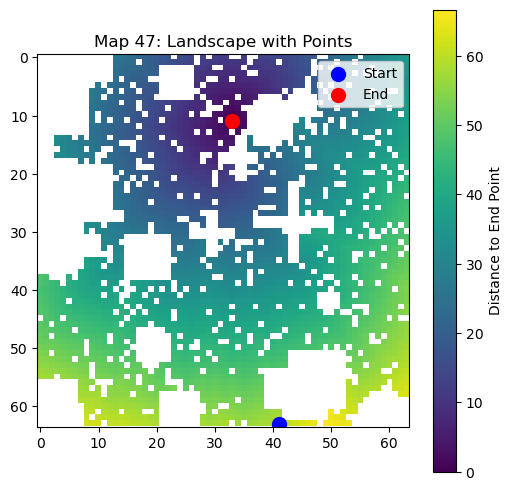

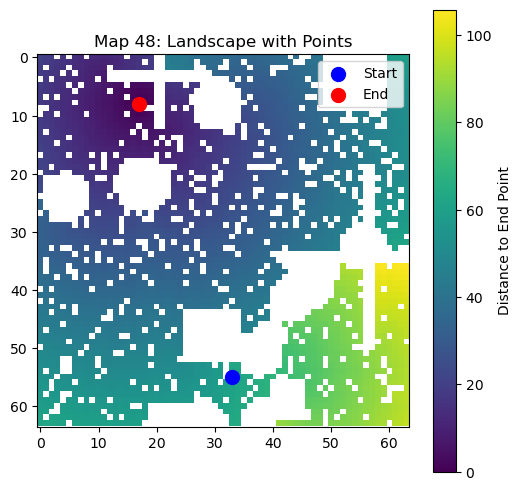

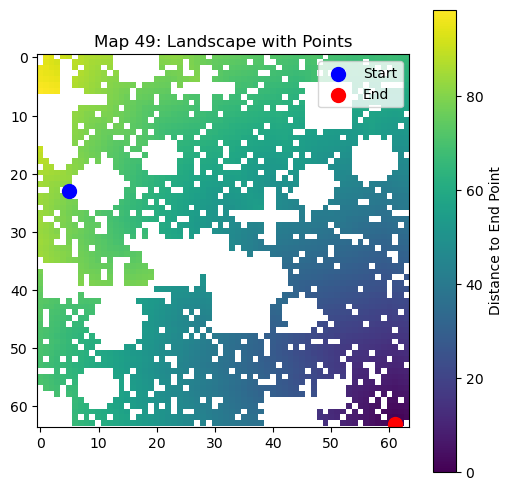

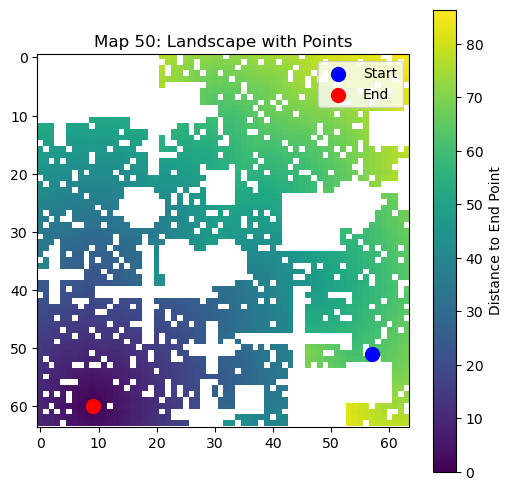

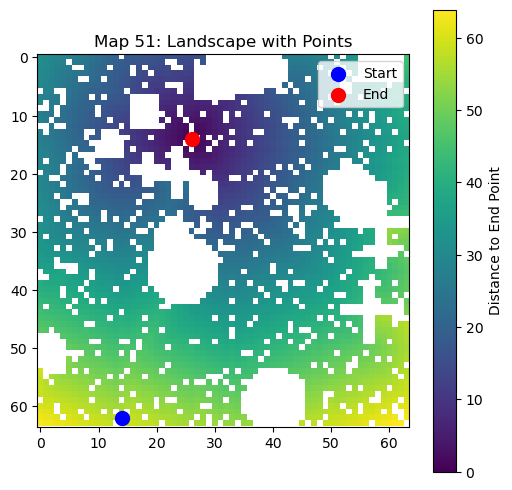

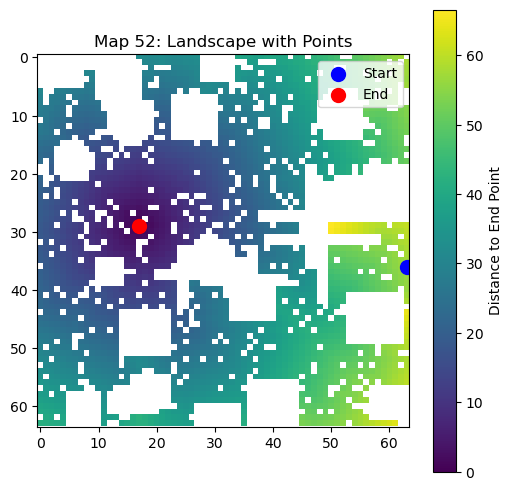

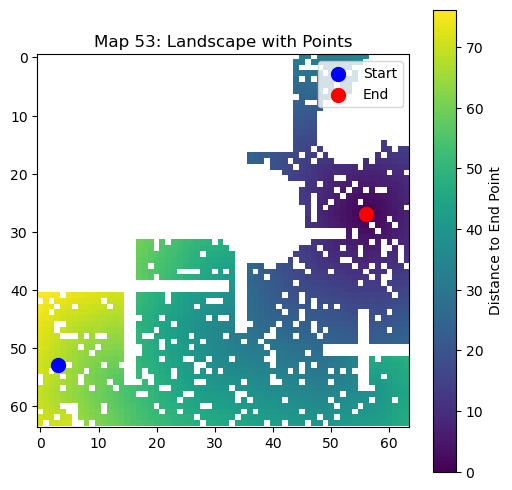

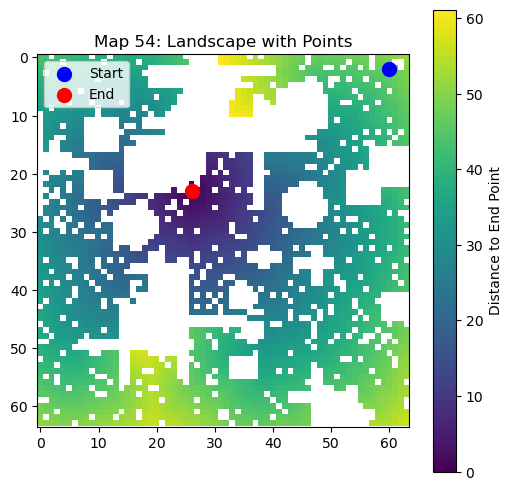

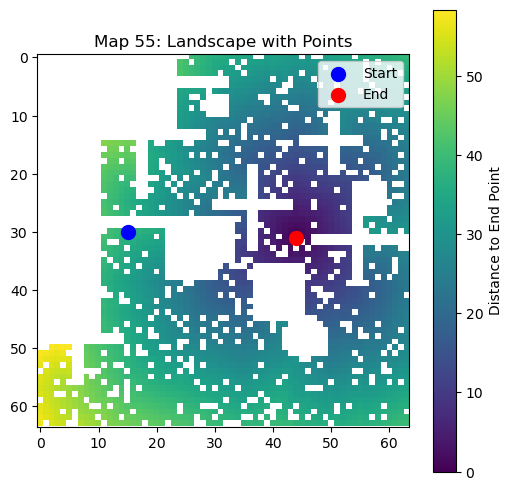

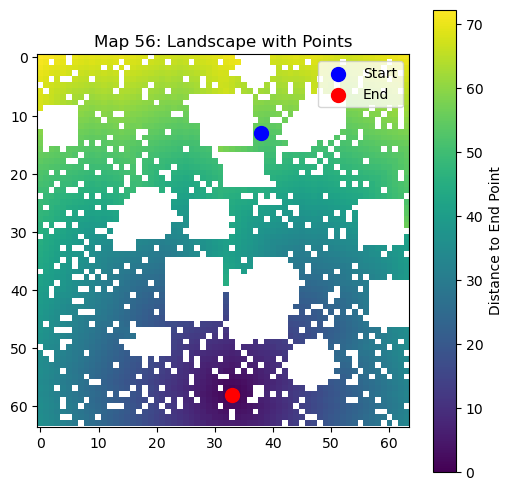

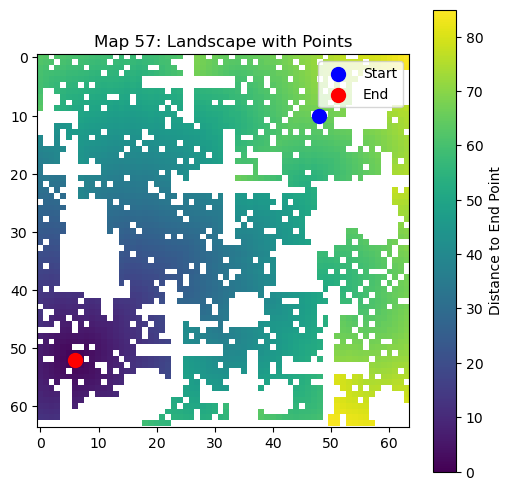

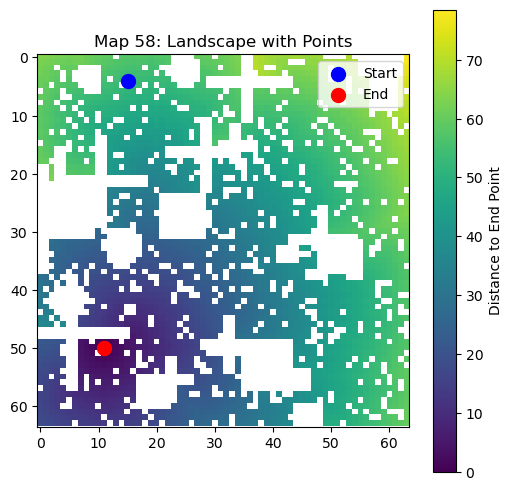

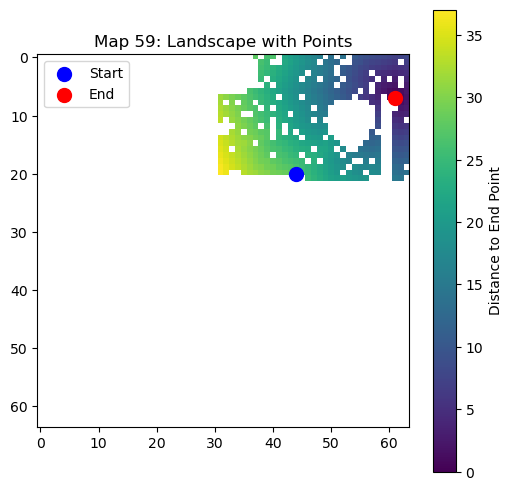

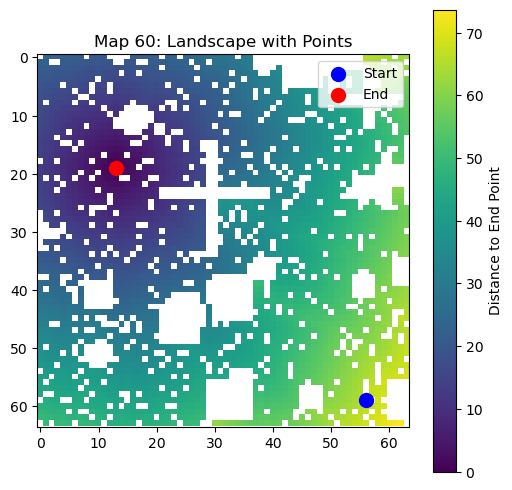

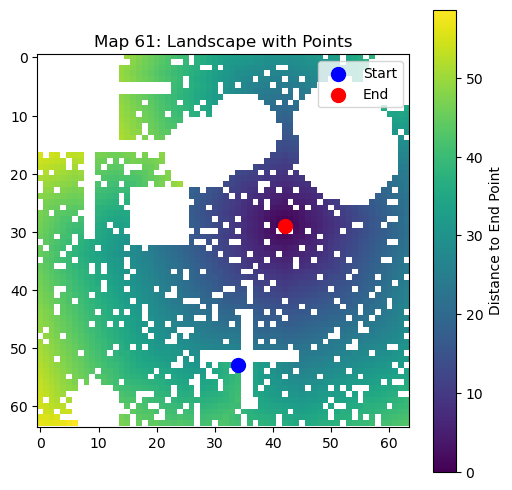

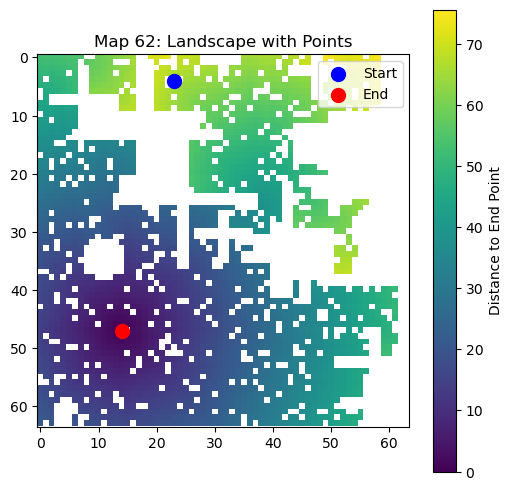

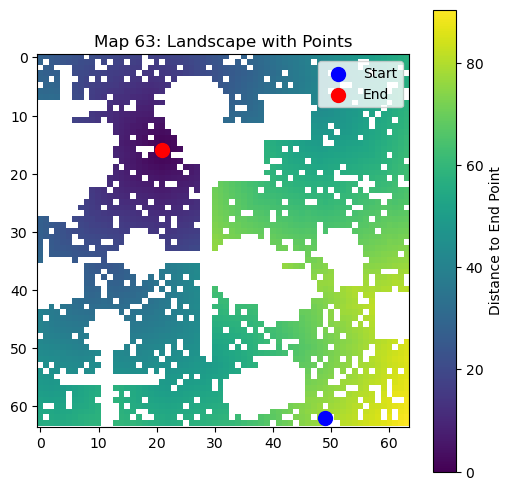

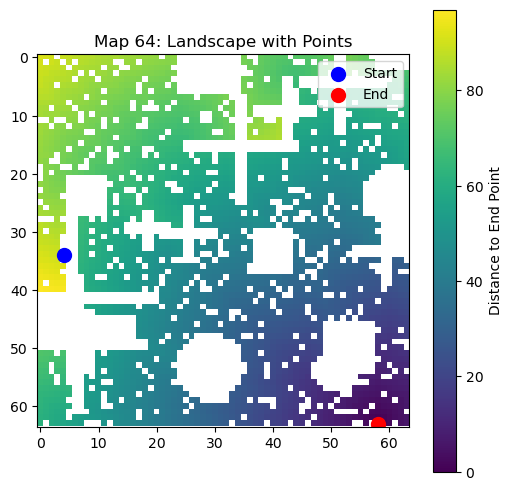

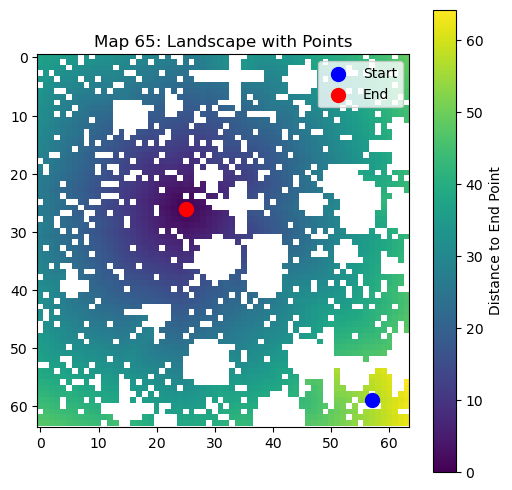

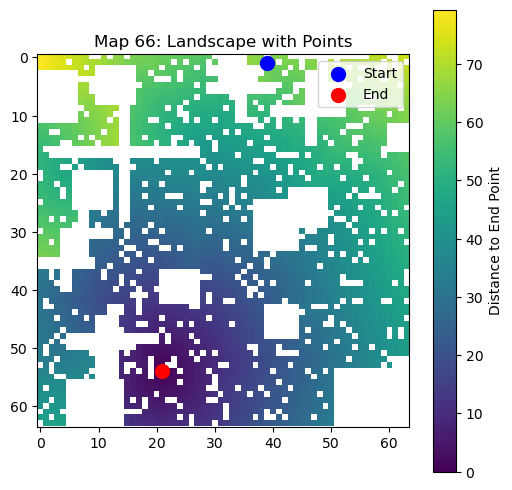

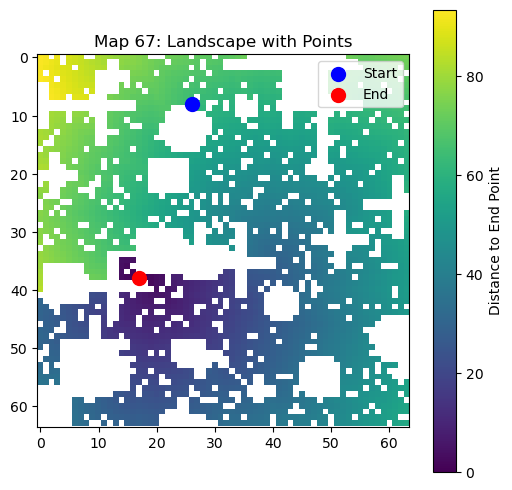

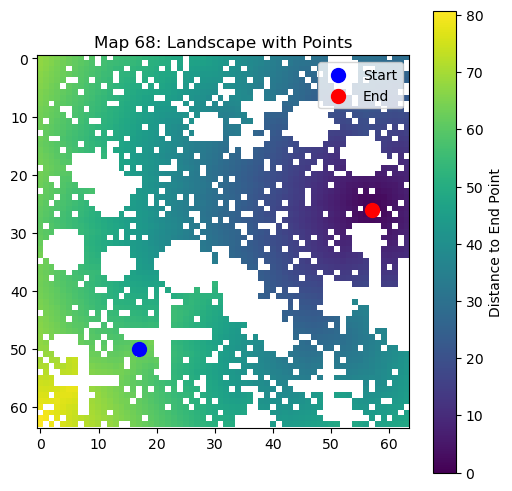

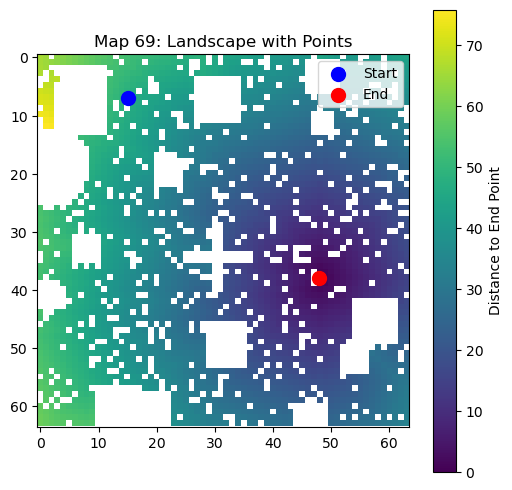

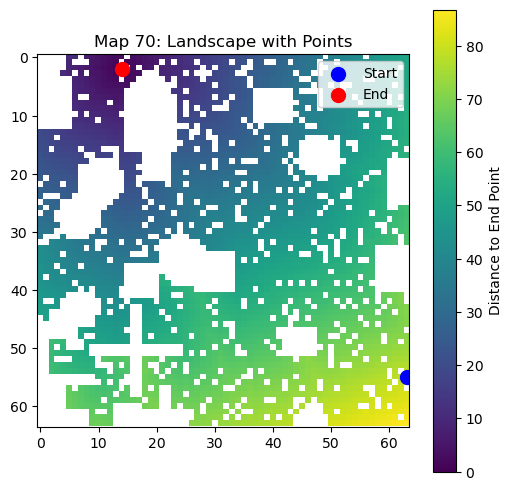

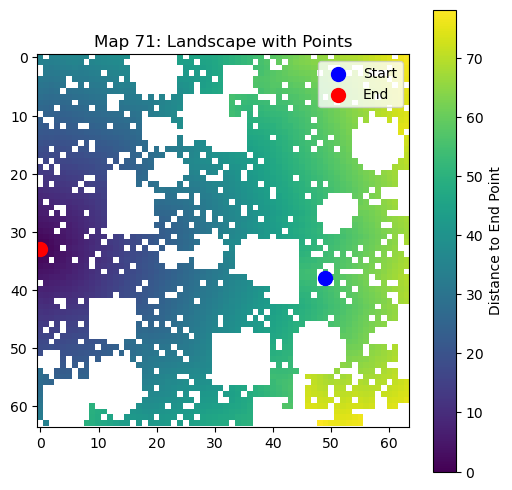

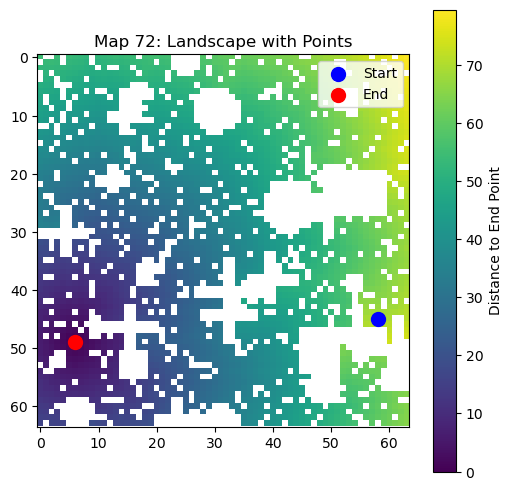

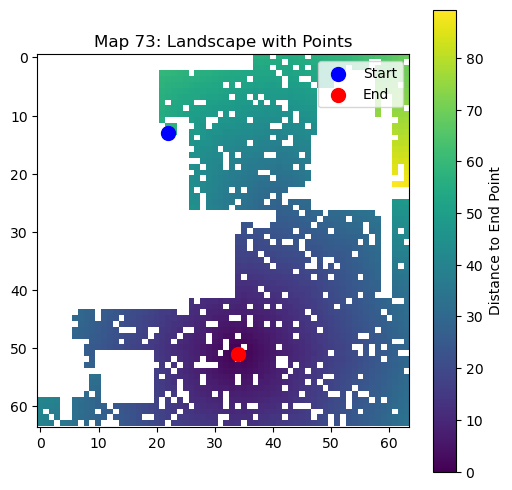

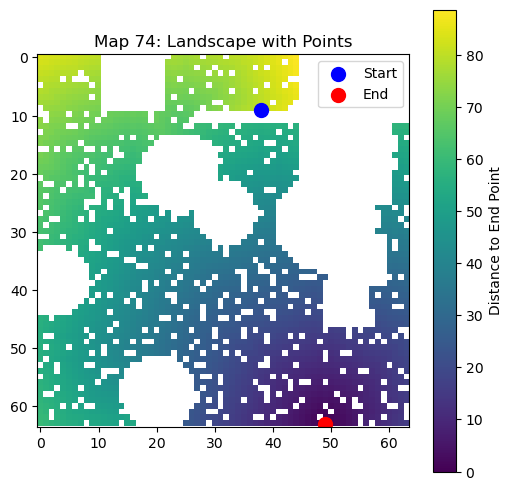

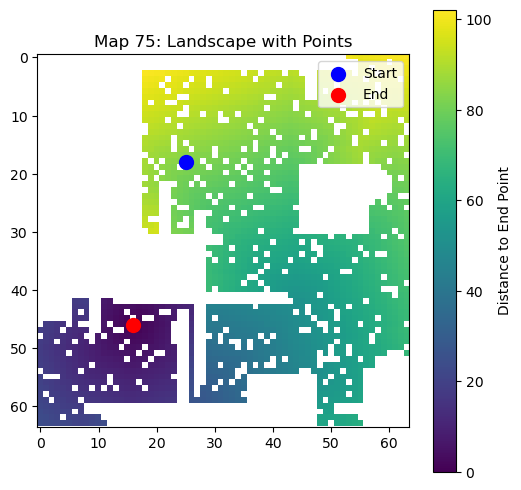

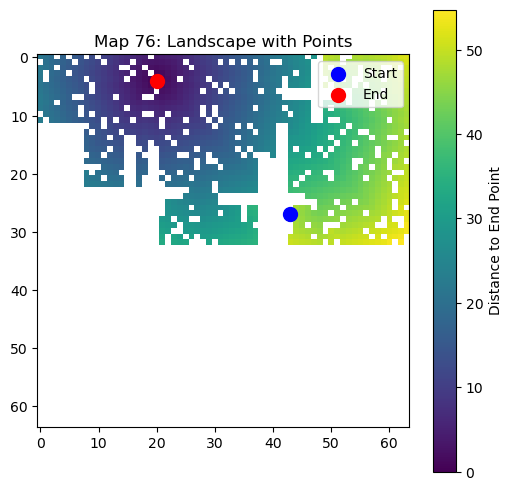

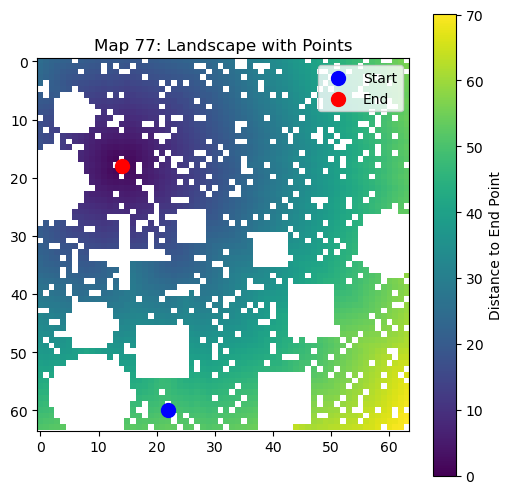

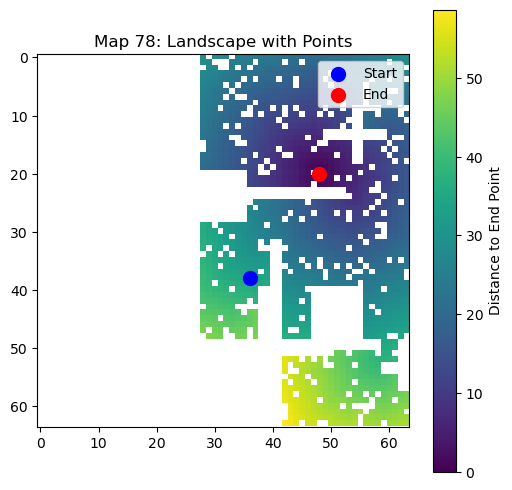

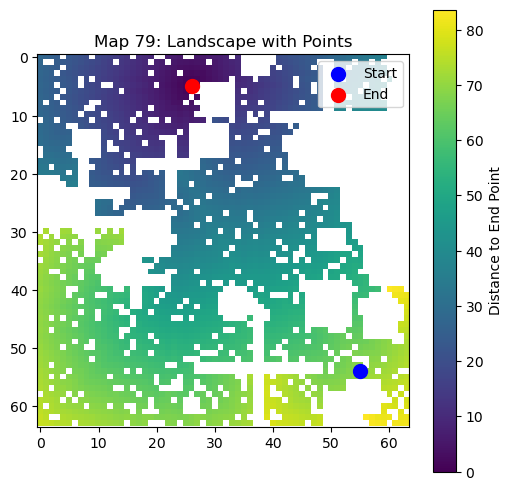

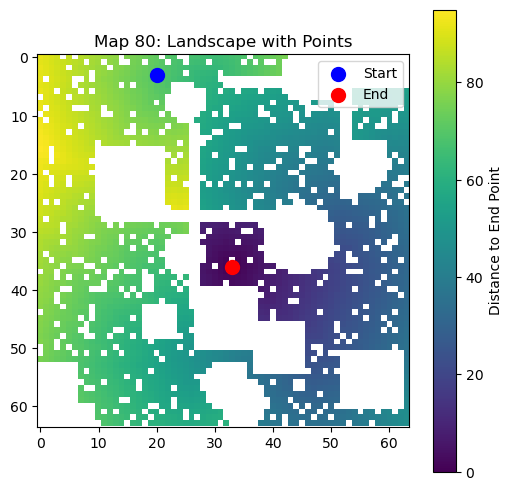

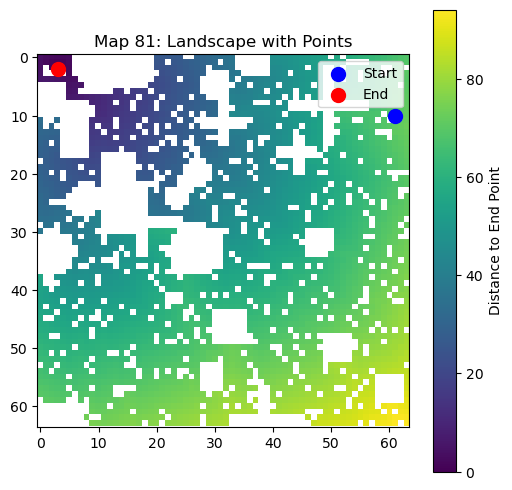

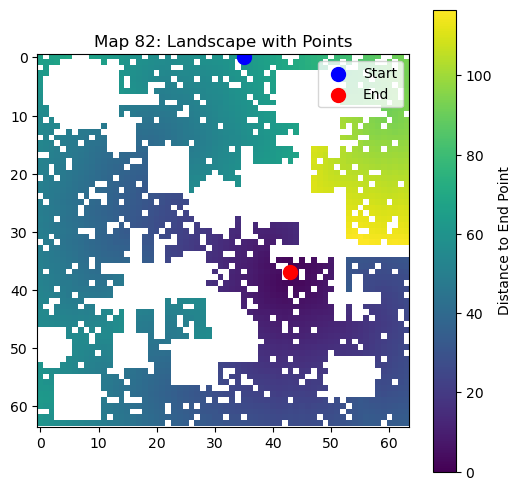

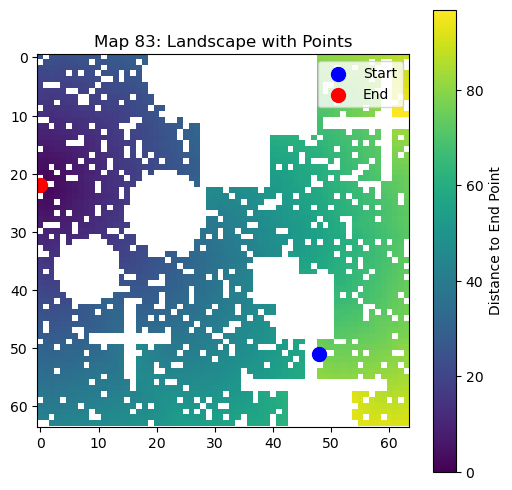

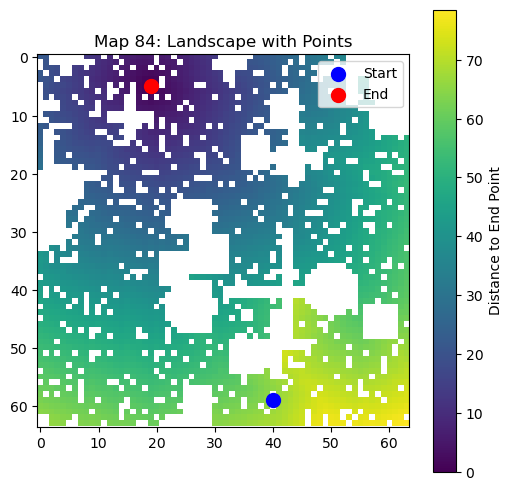

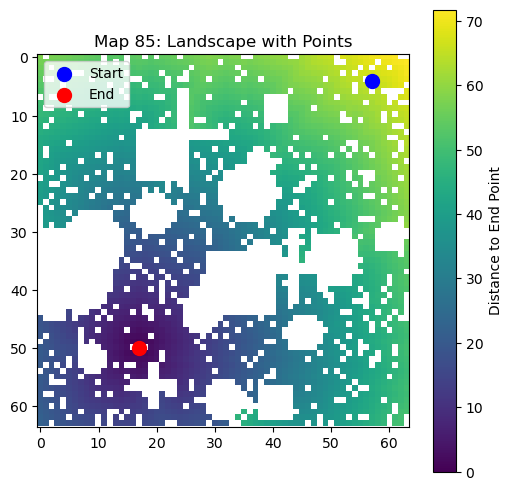

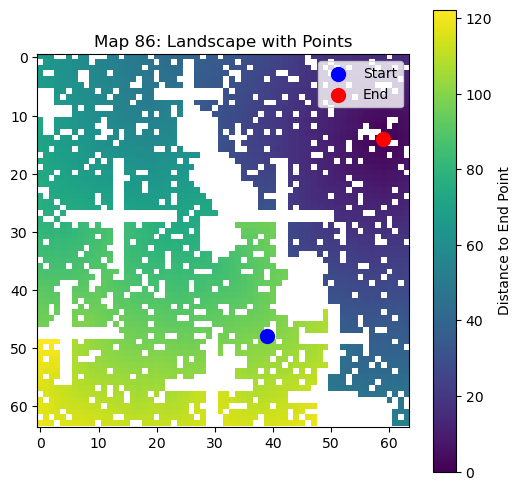

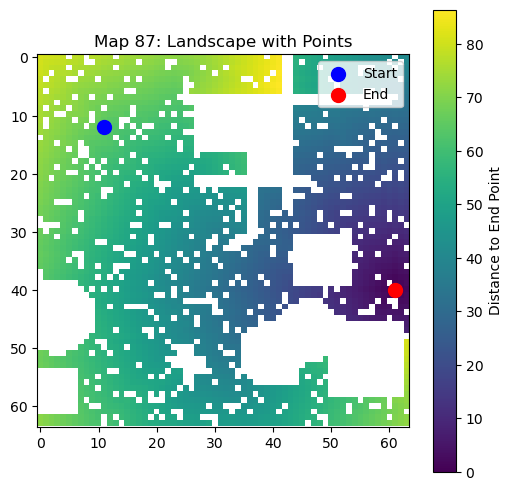

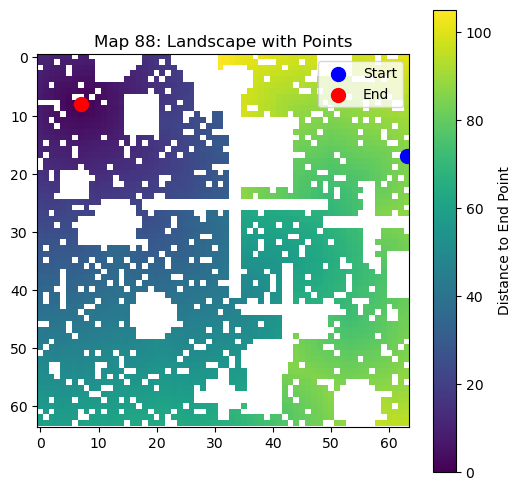

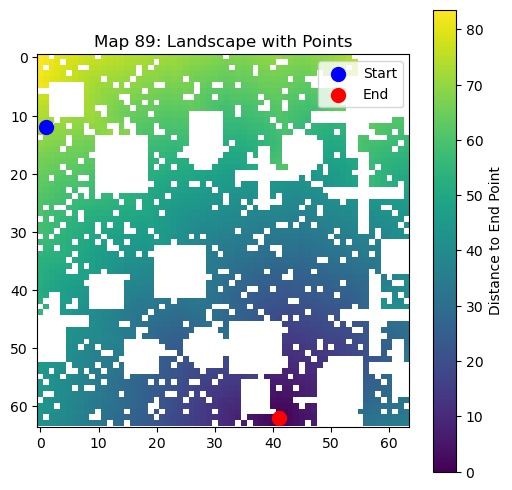

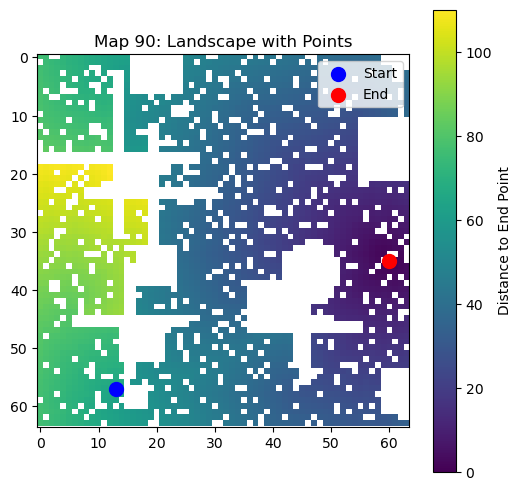

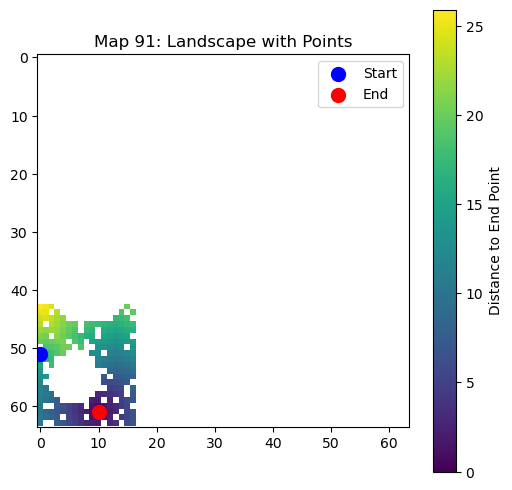

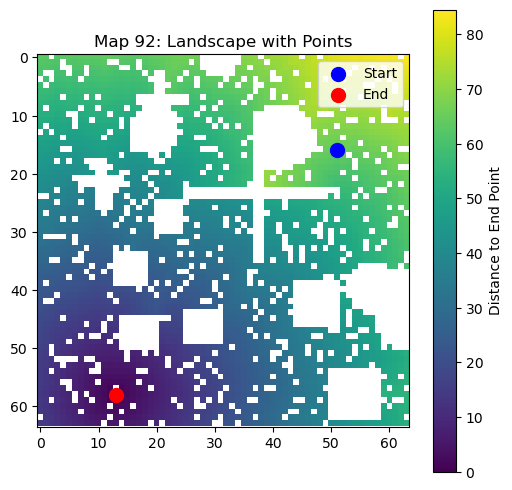

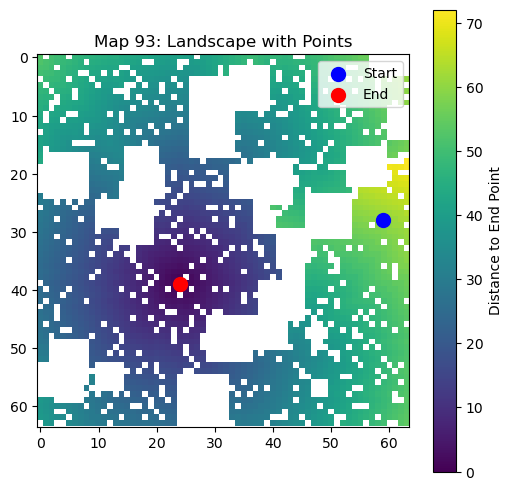

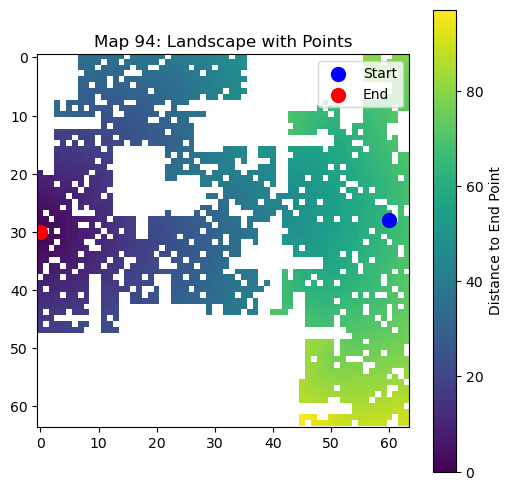

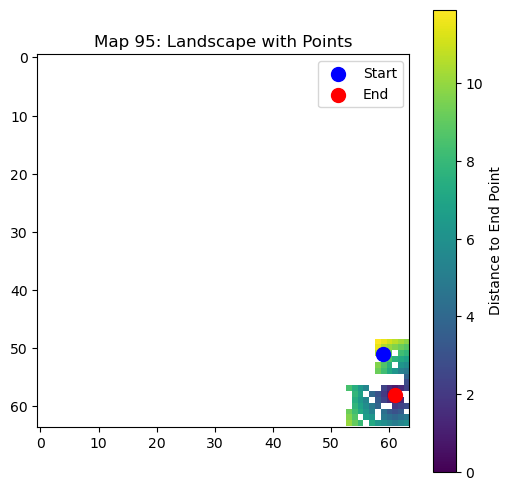

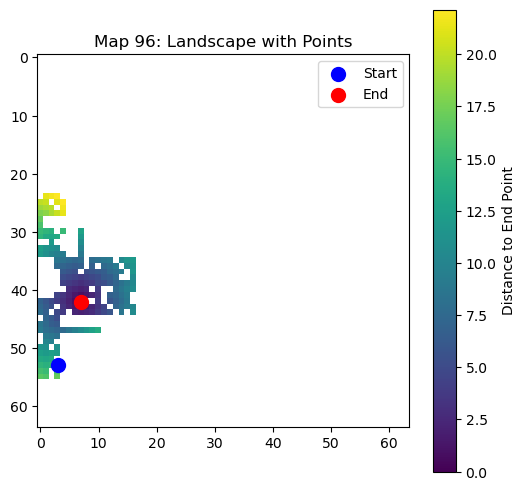

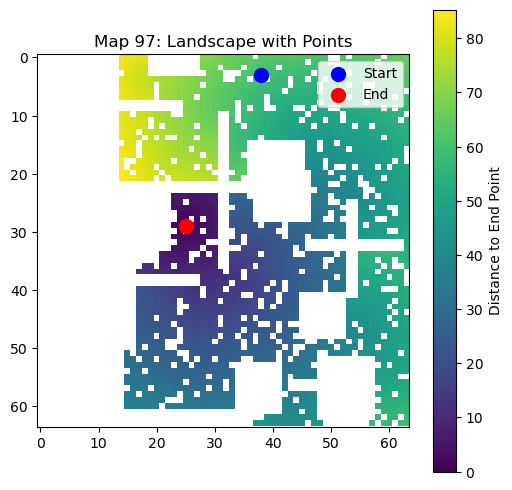

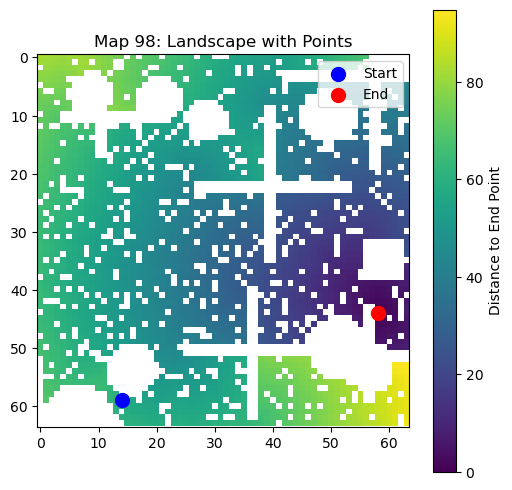

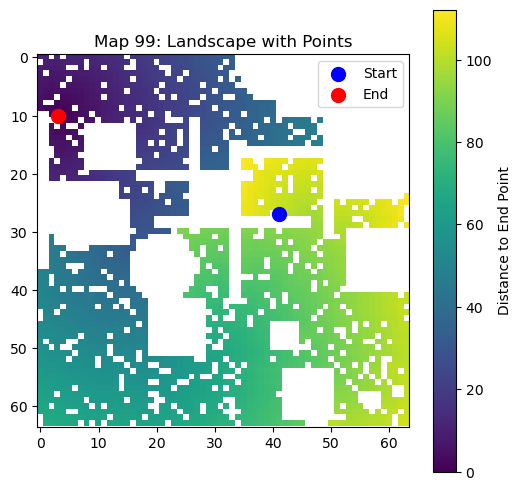

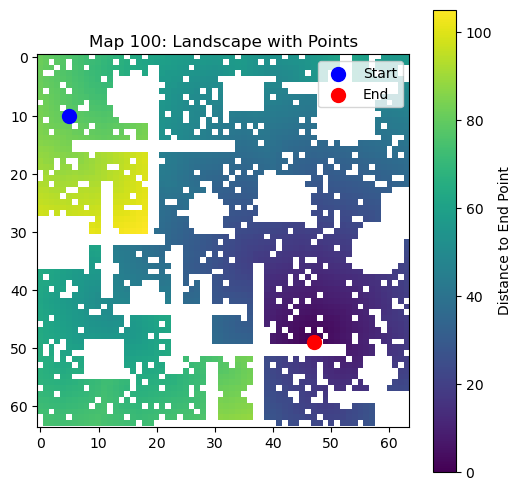

In [16]:
plot_multiple_maps(dataset)